In [19]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [20]:
os.makedirs('../graphics', exist_ok=True)

In [21]:
sns.set_style("white")
plt.rcParams['figure.figsize'] = (8, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['figure.facecolor'] = 'white'

color1 = '#344e41'
color2 = '#a3b18a'

colors = ['#344e41', '#a3b18a']

In [22]:
with open('../outputs/results.json', 'r') as f:
    results = json.load(f)

with open('../results/pass1.json', 'r') as f:
    pass1 = json.load(f)


## Calculate Metrics

In [23]:
records = []
for model_name, model_data in results.items():
    for task in model_data:
        for shot in ['0', '3']:
            energy_key = f'energy_{shot}'
            time_key = f'time_{shot}'
            if energy_key in task and time_key in task:
                records.append({
                    'model': 'CodeLlama' if model_name == 'codellama' else 'Meta-Llama',
                    'shot': f'{shot}-shot',
                    'energy_joules': task[energy_key],
                    'time_seconds': task[time_key]
                })

df_main = pd.DataFrame(records)

# Agregar por modelo (média entre 0-shot e 3-shot) para as alíneas a, b, c
df_model_avg = df_main.groupby('model').agg({
    'energy_joules': 'mean',
    'time_seconds': 'mean'
}).reset_index()
df_model_avg.columns = ['model', 'energy_mean', 'time_mean']

In [24]:
pass1_records = []
for model_name, strategies in pass1.items():
    for shot, data in strategies.items():
        pass1_records.append({
            'model': 'CodeLlama' if model_name == 'codellama' else 'Meta-Llama',
            'shot': shot,
            'pass@1': data['pass@1_avg']
        })
df_pass1 = pd.DataFrame(pass1_records)

# Agregar por modelo (média entre 0-shot e 3-shot) para a alínea c
df_pass1_model = df_pass1.groupby('model').agg({'pass@1': 'mean'}).reset_index()

In [25]:
# Juntar tudo
df_summary_model = df_model_avg.merge(df_pass1_model, on='model')
print("Resumo das métricas por modelo (média entre 0-shot e 3-shot):")
print(df_summary_model.to_string(index=False))

Resumo das métricas por modelo (média entre 0-shot e 3-shot):
     model  energy_mean  time_mean  pass@1
 CodeLlama     0.000009  18.142123     0.4
Meta-Llama     0.000009  22.477451     0.2


## Alínea a - Energy Efficiency

C:\Users\inesg\AppData\Local\Temp\ipykernel_22536\1509334247.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_summary_model, x='model', y='energy_mean',


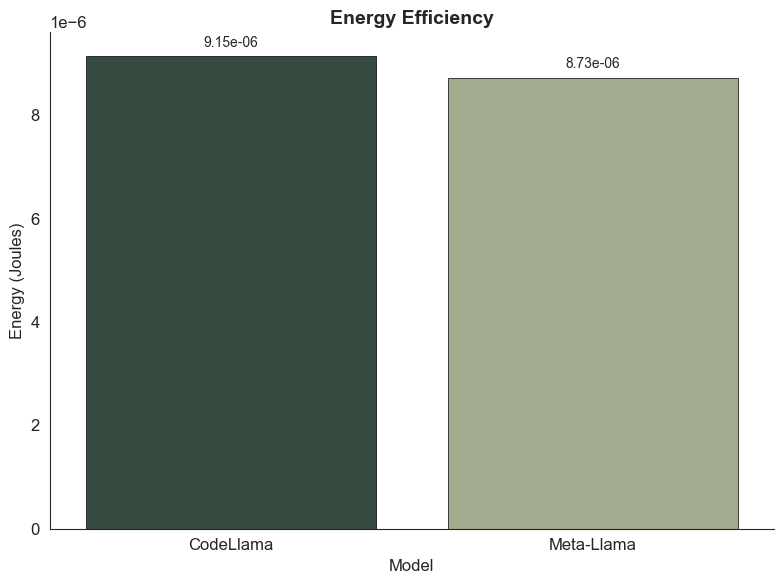


 Best Model for Energy Efficiency: Meta-Llama


In [26]:
plt.figure(figsize=(8, 6))

ax = sns.barplot(data=df_summary_model, x='model', y='energy_mean', 
                 palette=colors, edgecolor='black', linewidth=0.5)

# Remover linhas de fundo
ax.set_facecolor('white')
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(True)
ax.spines['bottom'].set_visible(True)

# Títulos e labels
plt.title('Energy Efficiency', fontsize=14, fontweight='bold')
plt.ylabel('Energy (Joules)', fontsize=12)
plt.xlabel('Model', fontsize=12)

# Adicionar valores nas barras
for i, v in enumerate(df_summary_model['energy_mean']):
    ax.text(i, v + max(df_summary_model['energy_mean'])*0.02, f'{v:.2e}', 
            ha='center', fontsize=10)

# Ajustar layout e guardar
plt.tight_layout()
plt.savefig('../graphics/7a_energy_efficiency.png', dpi=300, bbox_inches='tight')
plt.show()

best_energy = df_summary_model.loc[df_summary_model['energy_mean'].idxmin()]
print(f"\n Best Model for Energy Efficiency: {best_energy['model']}")

## Alínea b - Inference Speed

C:\Users\inesg\AppData\Local\Temp\ipykernel_22536\1701819683.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_summary_model, x='model', y='time_mean',


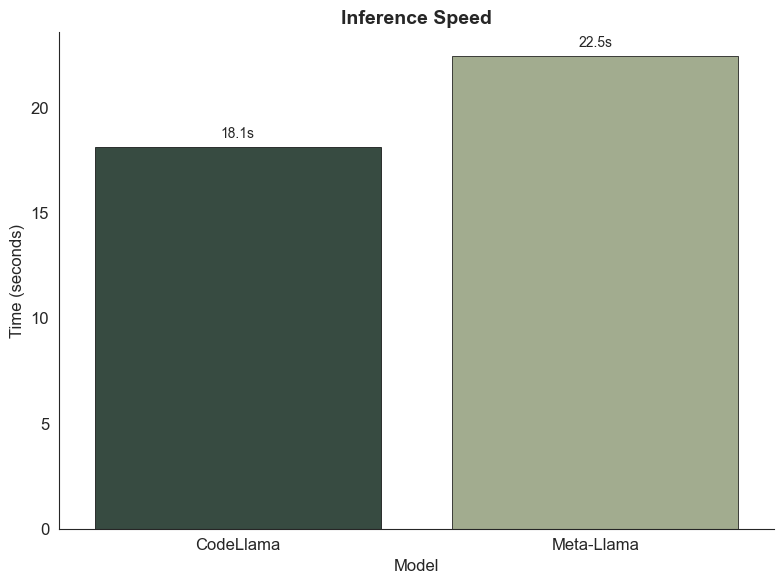


 Best Model for Inference Speed: CodeLlama


In [27]:
plt.figure(figsize=(8, 6))

ax = sns.barplot(data=df_summary_model, x='model', y='time_mean', 
                 palette=colors, edgecolor='black', linewidth=0.5)

ax.set_facecolor('white')
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(True)
ax.spines['bottom'].set_visible(True)

plt.title('Inference Speed', fontsize=14, fontweight='bold')
plt.ylabel('Time (seconds)', fontsize=12)
plt.xlabel('Model', fontsize=12)

for i, v in enumerate(df_summary_model['time_mean']):
    ax.text(i, v + max(df_summary_model['time_mean'])*0.02, f'{v:.1f}s', 
            ha='center', fontsize=10)

# Ajustar layout e guardar
plt.tight_layout()
plt.savefig('../graphics/7b_inference_speed.png', dpi=300, bbox_inches='tight')
plt.show()

best_time = df_summary_model.loc[df_summary_model['time_mean'].idxmin()]
print(f"\n Best Model for Inference Speed: {best_time['model']}")

## Alínea c - Functional Correctness

C:\Users\inesg\AppData\Local\Temp\ipykernel_22536\1886933530.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_summary_model, x='model', y='pass@1',


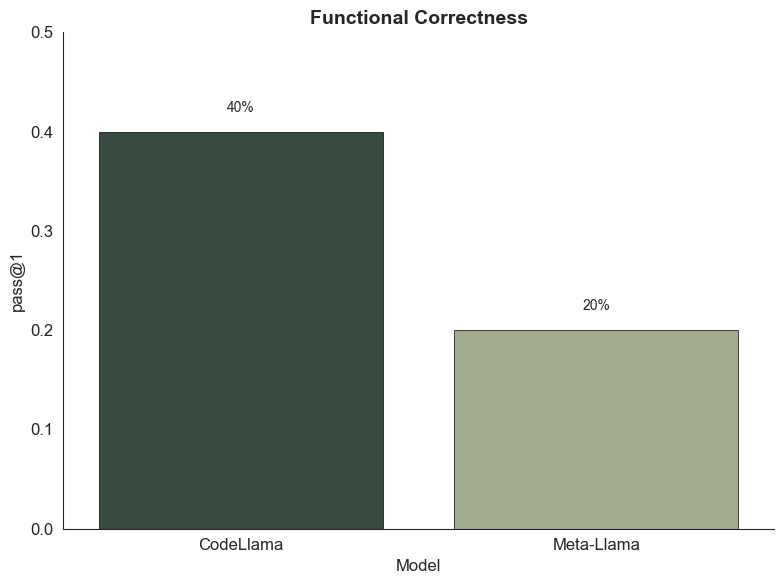


 Best Model for Functional Correctness: CodeLlama


In [28]:
plt.figure(figsize=(8, 6))

ax = sns.barplot(data=df_summary_model, x='model', y='pass@1', 
                 palette=colors, edgecolor='black', linewidth=0.5)

ax.set_facecolor('white')
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(True)
ax.spines['bottom'].set_visible(True)

plt.title('Functional Correctness', fontsize=14, fontweight='bold')
plt.ylabel('pass@1', fontsize=12)
plt.xlabel('Model', fontsize=12)
plt.ylim(0, 0.5)

for i, v in enumerate(df_summary_model['pass@1']):
    ax.text(i, v + 0.02, f'{v*100:.0f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('../graphics/7c_functional_correctness.png', dpi=300, bbox_inches='tight')
plt.show()

best_pass = df_summary_model.loc[df_summary_model['pass@1'].idxmax()]
print(f"\n Best Model for Functional Correctness: {best_pass['model']}")

## Alínea d - Prompting Strategy

In [29]:
df_shot = df_main.groupby(['model', 'shot']).agg({
    'energy_joules': 'mean',
    'time_seconds': 'mean'
}).reset_index()
df_shot = df_shot.merge(df_pass1, on=['model', 'shot'])

# Definir posições para as barras
models = ['CodeLlama', 'Meta-Llama']
shots = ['0-shot', '3-shot']
x = np.arange(len(models))  # [0, 1]
width = 0.35  # largura das barras

print("Dados para 7(d) - comparação 0-shot vs 3-shot:")
print(df_shot.to_string(index=False))

Dados para 7(d) - comparação 0-shot vs 3-shot:
     model   shot  energy_joules  time_seconds  pass@1
 CodeLlama 0-shot       0.000003     12.340173     0.3
 CodeLlama 3-shot       0.000016     23.944072     0.5
Meta-Llama 0-shot       0.000008     24.033264     0.0
Meta-Llama 3-shot       0.000009     20.921638     0.4


### Impact of 3-shot on Energy Efficiency

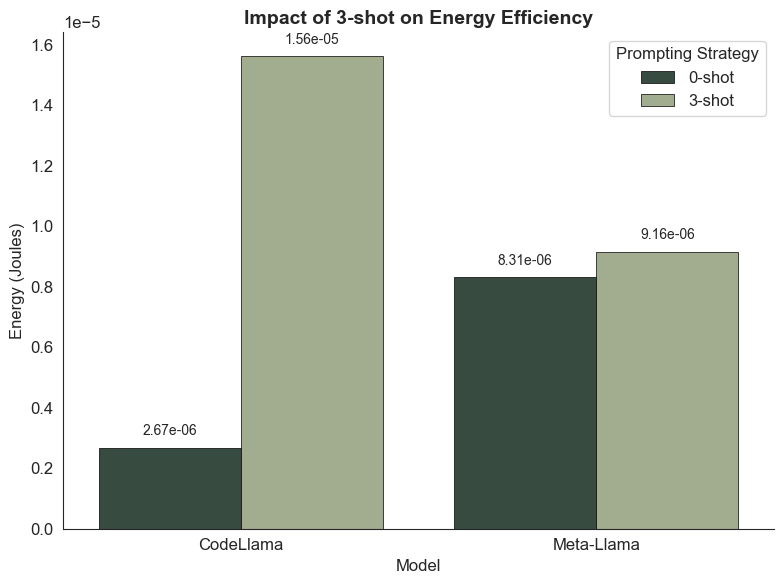


 Energetic Impact:
   CodeLlama: 2.67e-06 J → 1.56e-05 J (aumento de 484.6%)
   Meta-Llama: 8.31e-06 J → 9.16e-06 J (aumento de 10.2%)


In [30]:
plt.figure(figsize=(8, 6))

ax = sns.barplot(data=df_shot, x='model', y='energy_joules', 
                 hue='shot', palette=[color1, color2], 
                 edgecolor='black', linewidth=0.5)


ax.set_facecolor('white')
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(True)
ax.spines['bottom'].set_visible(True)

plt.title('Impact of 3-shot on Energy Efficiency', fontsize=14, fontweight='bold')
plt.ylabel('Energy (Joules)', fontsize=12)
plt.xlabel('Model', fontsize=12)
plt.legend(title='Prompting Strategy', frameon=True)

for i, bar in enumerate(ax.patches):
    height = bar.get_height()
    if height > 0:
        # Formatar cada valor individualmente
        if height < 1e-5:
            label = f'{height:.2e}'
        else:
            label = f'{height:.2e}'
        ax.text(bar.get_x() + bar.get_width()/2., height + max(df_shot['energy_joules'])*0.02,
                label, ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('../graphics/7d_energy_impact.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n Energetic Impact:")
for model in df_shot['model'].unique():
    row_0 = df_shot[(df_shot['model']==model) & (df_shot['shot']=='0-shot')].iloc[0]
    row_3 = df_shot[(df_shot['model']==model) & (df_shot['shot']=='3-shot')].iloc[0]
    print(f"   {model}: {row_0['energy_joules']:.2e} J → {row_3['energy_joules']:.2e} J (aumento de {(row_3['energy_joules']/row_0['energy_joules']-1)*100:.1f}%)")

### Impact of 3-shot on Inference Speed

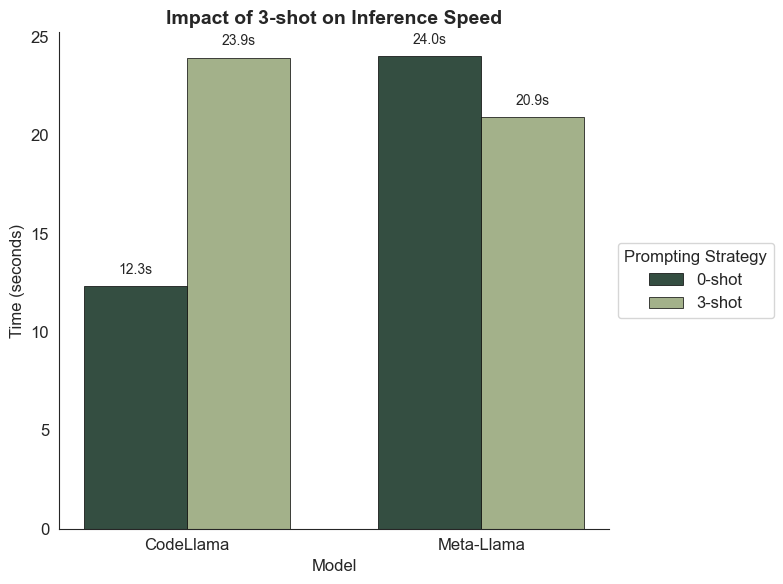


 Impact on Inference Speed:
   CodeLlama: 12.34s → 23.94s
   Meta-Llama: 24.03s → 20.92s


In [31]:
# Gráfico 7(d) - Tempo
fig, ax = plt.subplots(figsize=(8, 6))

# Extrair valores
time_0 = [df_shot[(df_shot['model']==m) & (df_shot['shot']=='0-shot')]['time_seconds'].values[0] for m in models]
time_3 = [df_shot[(df_shot['model']==m) & (df_shot['shot']=='3-shot')]['time_seconds'].values[0] for m in models]

# Barras
bars1 = ax.bar(x - width/2, time_0, width, label='0-shot', color=color1, edgecolor='black', linewidth=0.5)
bars2 = ax.bar(x + width/2, time_3, width, label='3-shot', color=color2, edgecolor='black', linewidth=0.5)

# Remover linhas de fundo
ax.set_facecolor('white')
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(True)
ax.spines['bottom'].set_visible(True)

# Títulos e labels
ax.set_title('Impact of 3-shot on Inference Speed', fontsize=14, fontweight='bold')
ax.set_ylabel('Time (seconds)', fontsize=12)
ax.set_xlabel('Model', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(models)

# Legenda à direita
ax.legend(title='Prompting Strategy', frameon=True, loc='center left', bbox_to_anchor=(1, 0.5))

# Adicionar valores acima das barras
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + max(time_0+time_3)*0.02,
            f'{height:.1f}s', ha='center', va='bottom', fontsize=10)
for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + max(time_0+time_3)*0.02,
            f'{height:.1f}s', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('../graphics/7d_time_impact.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n Impact on Inference Speed:")
for model in df_shot['model'].unique():
    row_0 = df_shot[(df_shot['model']==model) & (df_shot['shot']=='0-shot')].iloc[0]
    row_3 = df_shot[(df_shot['model']==model) & (df_shot['shot']=='3-shot')].iloc[0]
    print(f"   {model}: {row_0['time_seconds']:.2f}s → {row_3['time_seconds']:.2f}s")

### Impact of 3-shot on Functional Correctness

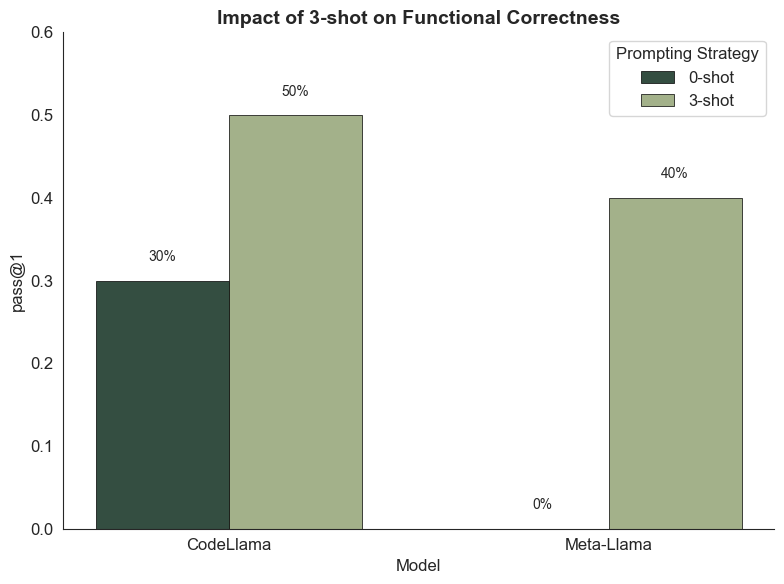


 Impacto on Functional Correctness:
   CodeLlama: 30% → 50%
   Meta-Llama: 0% → 40%


In [32]:
fig, ax = plt.subplots(figsize=(8, 6))

pass1_0 = [df_shot[(df_shot['model']==m) & (df_shot['shot']=='0-shot')]['pass@1'].values[0] for m in models]
pass1_3 = [df_shot[(df_shot['model']==m) & (df_shot['shot']=='3-shot')]['pass@1'].values[0] for m in models]

bars1 = ax.bar(x - width/2, pass1_0, width, label='0-shot', color=color1, edgecolor='black', linewidth=0.5)
bars2 = ax.bar(x + width/2, pass1_3, width, label='3-shot', color=color2, edgecolor='black', linewidth=0.5)

ax.set_facecolor('white')
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(True)
ax.spines['bottom'].set_visible(True)

ax.set_title('Impact of 3-shot on Functional Correctness', fontsize=14, fontweight='bold')
ax.set_ylabel('pass@1', fontsize=12)
ax.set_xlabel('Model', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0, 0.6)
ax.legend(title='Prompting Strategy', frameon=True)

# Adicionar valores acima das barras
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
            f'{height*100:.0f}%', ha='center', va='bottom', fontsize=10)
for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
            f'{height*100:.0f}%', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('../graphics/7d_pass1_impact.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n Impacto on Functional Correctness:")
for model in df_shot['model'].unique():
    row_0 = df_shot[(df_shot['model']==model) & (df_shot['shot']=='0-shot')].iloc[0]
    row_3 = df_shot[(df_shot['model']==model) & (df_shot['shot']=='3-shot')].iloc[0]
    print(f"   {model}: {row_0['pass@1']*100:.0f}% → {row_3['pass@1']*100:.0f}%")